# 06 — RQ3: two-stage sentiment evaluation (guide §8) — SMOKE

Ground truth: `labels.intended_sentiment`.

- **Stage 1 (pre-sarcasm):** the shipped `aux.tx_sentiment` probabilities
  (external, model-independent — the guide's primary candidate).
- **Stage 2 (post-sarcasm):** rows the sarcasm model flags get their sentiment
  re-predicted by a small head trained on `intended_sentiment` over the FROZEN
  `[t ; c_fused]` features exported by notebook 04; unflagged rows keep stage 1.

The interesting cell is *sarcastic ∧ literal≠intended* — where
sarcasm-awareness must show its value. **Every number is SMOKE.**

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from leische import data as D
from leische import evaluate as E
from leische.nbsupport import bootstrap

cfg, df, corpus, card, gate = bootstrap(config="configs/smoke.yaml", run_name="smoke-rq3")
SMOKE = cfg.tag()
folds = D.load_folds(cfg.folds_file(), card)

 SMOKE MODE — every number in this notebook is a harness or
 architecture check on the pilot export, NOT a reportable result.
dataset identity: {'dataset_version': 'v1', 'prompt_version': 'sarc-v1', 'uyam_commit': '69d0affaca157edaf64e617d21e8ae752c9343fa'}
rows: 100  sarcastic: 8  corpus: not loaded

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [PASS] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.


## The polarity-shift landscape (why RQ3 exists)

In [2]:
literal = df["labels"].map(lambda l: l["literal_sentiment"])
intended = df["labels"].map(lambda l: l["intended_sentiment"])
sarc = D.sarcastic(df)
shift = literal != intended
print(f"{SMOKE}rows with literal≠intended: {shift.sum()} / {len(df)}")
print(f"{SMOKE}sarcastic ∧ literal≠intended: {(sarc & shift).sum()} rows "
      "(the cell where stage 2 must earn its keep)")
print(f"\n{SMOKE}literal → intended transitions among sarcastic rows:")
print(pd.crosstab(literal[sarc], intended[sarc]))

SMOKE rows with literal≠intended: 4 / 100
SMOKE sarcastic ∧ literal≠intended: 3 rows (the cell where stage 2 must earn its keep)

SMOKE literal → intended transitions among sarcastic rows:
labels    negative
labels            
negative         5
neutral          2
positive         1


## Stage 1 — external sentiment classifier vs intended_sentiment

In [3]:
stage1 = E.stage1_tx_predictions(df)
print(f"{SMOKE}stage-1 (tx_sentiment argmax) vs intended_sentiment, all 100 rows:")
print(E.rq3_report(df, stage1, tag=SMOKE + "stage1").to_string(index=False))

SMOKE stage-1 (tx_sentiment argmax) vs intended_sentiment, all 100 rows:
         run                        slice  macro_f1  accuracy   n
SMOKE stage1                      overall  0.680390  0.670000 100
SMOKE stage1             language=english  0.807708  0.821429  28
SMOKE stage1             language=tagalog  0.329412  0.470588  17
SMOKE stage1             language=taglish  0.660059  0.654545  55
SMOKE stage1         gold_sarcastic=False  0.671717  0.673913  92
SMOKE stage1          gold_sarcastic=True  0.256410  0.625000   8
SMOKE stage1 sarcastic ∧ literal≠intended  0.266667  0.666667   3


## Stage 2 — sarcasm-aware reinterpretation (fold-0 protocol)

Head trained on fold-0 TRAIN rows' frozen features only; evaluated on fold-0
TEST rows. Sarcasm flags come from the notebook-04 smoke checkpoint.

In [4]:
z = np.load(cfg.cache_path() / "smoke_full_features.npz", allow_pickle=True)
feat_of = {f: i for i, f in enumerate(z["fullnames"])}
flags = dict(zip(z["fullnames"], z["pred"].astype(bool)))

fold0 = folds[0]
X = z["features"]
y_intended = dict(zip(df["reddit_fullname"], intended))

train_idx = [feat_of[f] for f in fold0["train"]]
head = LogisticRegression(max_iter=2000)
head.fit(X[train_idx], [y_intended[f] for f in fold0["train"]])
print(f"{SMOKE}stage-2 head trained on {len(train_idx)} fold-0 train rows "
      f"(classes: {list(head.classes_)})")

SMOKE stage-2 head trained on 77 fold-0 train rows (classes: [np.str_('negative'), np.str_('neutral'), np.str_('positive')])


In [5]:
test_df = df[df["reddit_fullname"].isin(fold0["test"])].copy()
test_names = test_df["reddit_fullname"].tolist()
s1_test = E.stage1_tx_predictions(test_df)
flagged = pd.Series([flags[f] for f in test_names], index=test_df.index)
s2_test = pd.Series(head.predict(X[[feat_of[f] for f in test_names]]), index=test_df.index)
final = E.two_stage_predictions(test_df, s1_test, flagged, s2_test)
print(f"{SMOKE}fold-0 test: {len(test_df)} rows, {int(flagged.sum())} flagged sarcastic "
      f"by the smoke model")

SMOKE fold-0 test: 20 rows, 0 flagged sarcastic by the smoke model


In [6]:
print(f"{SMOKE}RQ3 comparison on fold-0 test rows (macro-F1 vs intended_sentiment):")
r1 = E.rq3_report(test_df, s1_test, tag=SMOKE + "stage1-only")
r2 = E.rq3_report(test_df, final, tag=SMOKE + "two-stage")
print(pd.concat([r1, r2], ignore_index=True).to_string(index=False))
print(f"\n{SMOKE}the pilot's fold-0 test slice holds ≤2 sarcastic rows — these tables "
      "prove the pipeline shape (per-language, per-gold-label, shift slice), nothing more.")

SMOKE RQ3 comparison on fold-0 test rows (macro-F1 vs intended_sentiment):
              run                        slice  macro_f1  accuracy  n
SMOKE stage1-only                      overall  0.651852  0.700000 20
SMOKE stage1-only             language=english  0.777778  0.750000  4
SMOKE stage1-only             language=tagalog  0.166667  0.333333  3
SMOKE stage1-only             language=taglish  0.691667  0.769231 13
SMOKE stage1-only         gold_sarcastic=False  0.651852  0.700000 20
SMOKE stage1-only          gold_sarcastic=True       NaN       NaN  0
SMOKE stage1-only sarcastic ∧ literal≠intended       NaN       NaN  0
  SMOKE two-stage                      overall  0.651852  0.700000 20
  SMOKE two-stage             language=english  0.777778  0.750000  4
  SMOKE two-stage             language=tagalog  0.166667  0.333333  3
  SMOKE two-stage             language=taglish  0.691667  0.769231 13
  SMOKE two-stage         gold_sarcastic=False  0.651852  0.700000 20
  SMOKE two-sta

## Calibration note (§9.8)

RQ3 stage-2 quality depends on WHICH rows get flagged; a badly calibrated
flag ruins the sentiment story. ECE + reliability curve for the smoke flags:

SMOKE sarcasm-flag ECE on fold-0 test: 0.4776


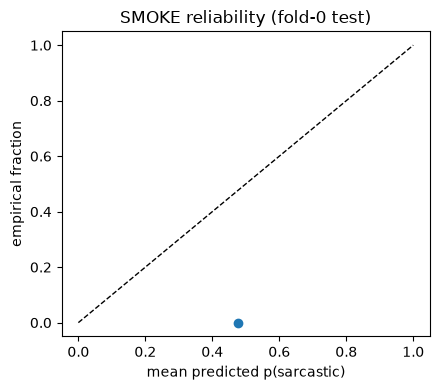

temperature scaling + F1-optimal thresholding exist behind config flags (temperature_scaling, tune_threshold_on_val) — evaluated post-gate.


In [7]:
import matplotlib.pyplot as plt

y_true_sarc = test_df["labels"].map(lambda l: int(l["sarcastic"])).to_numpy()
probs = z["prob"][[feat_of[f] for f in test_names]]
print(f"{SMOKE}sarcasm-flag ECE on fold-0 test: {E.ece(y_true_sarc, probs):.4f}")
curve = E.reliability_curve(y_true_sarc, probs)
if len(curve):
    plt.figure(figsize=(4.5, 4))
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.plot(curve["mean_prob"], curve["frac_pos"], "o-")
    plt.xlabel("mean predicted p(sarcastic)"); plt.ylabel("empirical fraction")
    plt.title(f"{SMOKE}reliability (fold-0 test)")
    plt.tight_layout(); plt.show()
print("temperature scaling + F1-optimal thresholding exist behind config flags "
      "(temperature_scaling, tune_threshold_on_val) — evaluated post-gate.")

## Verdict

In [8]:
print(f"{SMOKE}RQ3 pipeline exercised end-to-end: external stage-1, model-flagged "
      "stage-2 reinterpretation on frozen features, disaggregated reporting incl. "
      "the sarcastic∧shift slice. Re-run against dataset-v2 once the §10 gate passes.")

SMOKE RQ3 pipeline exercised end-to-end: external stage-1, model-flagged stage-2 reinterpretation on frozen features, disaggregated reporting incl. the sarcastic∧shift slice. Re-run against dataset-v2 once the §10 gate passes.
